## Init project
### 导入库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

### 加载数据

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature shape:", X.shape)
print("Label shape:", y.shape)
print(data.target_names)

Feature shape: (569, 30)
Label shape: (569,)
['malignant' 'benign']


### 查看数据

In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 看类别分布

In [4]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

## Train Logistic Model
### 划分训练集和测试集

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


### 标准化

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First row before scaling:")
print(X_train[0])

print("\nFirst row after scaling:")
print(X_train_scaled[0])

First row before scaling:
[9.029e+00 1.733e+01 5.879e+01 2.505e+02 1.066e-01 1.413e-01 3.130e-01
 4.375e-02 2.111e-01 8.046e-02 3.274e-01 1.194e+00 1.885e+00 1.767e+01
 9.549e-03 8.606e-02 3.038e-01 3.322e-02 4.197e-02 9.559e-03 1.031e+01
 2.265e+01 6.550e+01 3.247e+02 1.482e-01 4.365e-01 1.252e+00 1.750e-01
 4.228e-01 1.175e-01]

First row after scaling:
[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
  2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
 -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
  2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
  0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]


### 训练 Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 查看最基础的准确率

In [11]:
from sklearn.metrics import accuracy_score

In [12]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9736842105263158


In [13]:
y_prob = model.predict_proba(X_test_scaled)

print(y_prob[:5])

[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]]


## Model Evaluation

In [14]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

### 查看 confusion matrix

In [15]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[41  2]
 [ 1 70]]


### 查看 classification report

In [16]:
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### 生成 confusion matrix

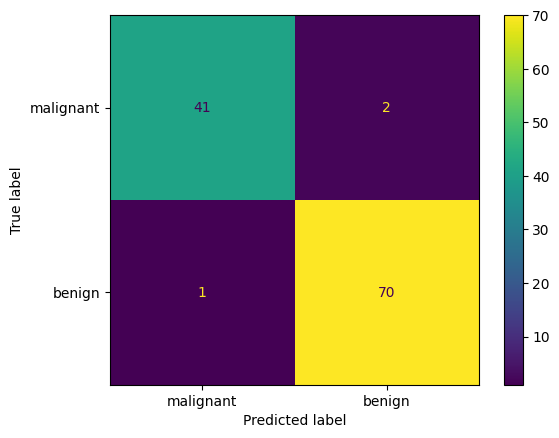

In [17]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.savefig("images/confusion_matrix.png", bbox_inches="tight")
plt.show()

### 查看模型参数

In [18]:
coefficients = model.coef_[0]
feature_names = data.feature_names

for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

mean radius: -0.4319
mean texture: -0.3873
mean perimeter: -0.3934
mean area: -0.4652
mean smoothness: -0.0717
mean compactness: 0.5402
mean concavity: -0.8015
mean concave points: -1.1198
mean symmetry: 0.2361
mean fractal dimension: 0.0759
radius error: -1.2682
texture error: 0.1889
perimeter error: -0.6106
area error: -0.9072
smoothness error: -0.3133
compactness error: 0.6825
concavity error: 0.1753
concave points error: -0.3113
symmetry error: 0.5004
fractal dimension error: 0.6162
worst radius: -0.8798
worst texture: -1.3506
worst perimeter: -0.5895
worst area: -0.8418
worst smoothness: -0.5442
worst compactness: 0.0161
worst concavity: -0.9431
worst concave points: -0.7782
worst symmetry: -1.2082
worst fractal dimension: -0.1574


### 排序

In [21]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

In [22]:
coef_df.head(10)

,feature,coefficient
15,compactness error,0.682491
19,fractal dimension error,0.616230
5,mean compactness,0.540164
18,symmetry error,0.500425
8,mean symmetry,0.236119
11,texture error,0.188877
16,concavity error,0.175275
9,mean fractal dimension,0.075921
25,worst compactness,0.016110
4,mean smoothness,-0.071667


In [23]:
coef_df.tail(10)

,feature,coefficient
27,worst concave points,-0.778217
6,mean concavity,-0.801458
23,worst area,-0.841846
20,worst radius,-0.879840
13,area error,-0.907186
26,worst concavity,-0.943053
7,mean concave points,-1.119804
28,worst symmetry,-1.208200
10,radius error,-1.268178
21,worst texture,-1.350606


### 画图

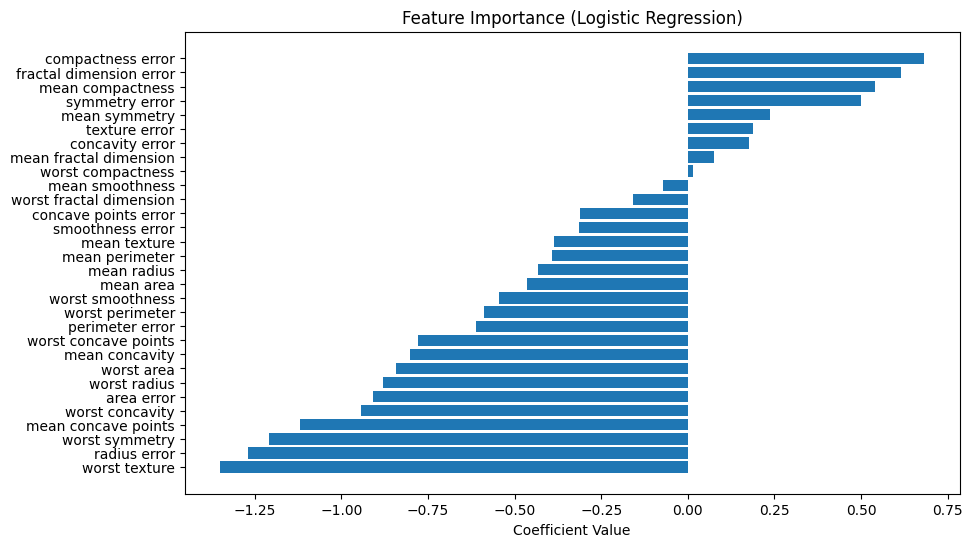

In [20]:
plt.figure(figsize=(10, 6))

coef_df_sorted = coef_df.sort_values(by="coefficient")

plt.barh(coef_df_sorted["feature"], coef_df_sorted["coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Logistic Regression)")
plt.show()